# Basic Market Analysis

Descriptive market analysis built on cached derived tables. The notebook focuses on distributions, returns, volatility, spreads, and trade activity.

Scope:
- descriptive diagnostics only
- no predictive modeling
- no OFI or cancel-like proxies

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def find_backtester_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        Path("../exchange-data-recorder/data") / symbol / day,
        Path("../exchange-data-recorder/data/binance") / symbol / day,
        project_root / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [3]:
symbol = "BTCUSDC"
day = "20260224"
grid_freq = "1s"
return_horizons = ["1s", "5s", "30s", "1min"]
vol_window = "5min"
replay_on_gap = "skip-segment"

day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)
day_dir

PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/BTCUSDC/20260224')

In [4]:
from stats.io import DEFAULT_BINANCE_QUOTE_ASSETS, load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_market_grid, get_or_build_top_of_book_table, get_or_build_trades_table

dataset = load_day(day_dir)
replay_info = replay_summary(dataset, replay_on_gap=replay_on_gap)
top_of_book = get_or_build_top_of_book_table(dataset, on_gap=replay_on_gap)
trades = get_or_build_trades_table(dataset)
market_grid = get_or_build_market_grid(dataset, grid_freq=grid_freq, on_gap=replay_on_gap)

dataset

### Asset Convention

The notebook reads `base_asset` and `quote_asset` from `schema.json` when the recorder stored instrument metadata. If that metadata is missing, the notebook falls back to symbol parsing and labels the result clearly. For separated symbols such as `BASE/QUOTE`, `BASE-QUOTE`, or `BASE QUOTE`, the first asset is treated as the base asset and the second asset is treated as the quote asset.

In [5]:
def split_symbol_by_separator(symbol: str) -> tuple[str, str] | None:
    for separator in ("/", "-", " "):
        if separator in symbol:
            left, right = symbol.split(separator, 1)
            left = left.strip().upper()
            right = right.strip().upper()
            if left and right:
                return left, right
    return None


def split_binance_symbol(symbol: str, quote_assets: tuple[str, ...] = DEFAULT_BINANCE_QUOTE_ASSETS) -> tuple[str, str]:
    matches = sorted((q for q in quote_assets if symbol.endswith(q)), key=len, reverse=True)
    if not matches:
        raise ValueError(f"Could not infer quote asset from symbol {symbol!r}")
    quote_asset = matches[0]
    base_asset = symbol[: -len(quote_asset)]
    if not base_asset:
        raise ValueError(f"Could not infer base asset from symbol {symbol!r}")
    return base_asset, quote_asset


def resolve_asset_convention(dataset) -> tuple[str, str, str, str]:
    instrument = getattr(dataset, "instrument", None)
    if instrument is not None and instrument.base_asset and instrument.quote_asset:
        source = instrument.asset_source or "schema"
        note = f"Loaded from schema.json instrument metadata ({source})."
        return instrument.base_asset, instrument.quote_asset, source, note

    separated = split_symbol_by_separator(dataset.symbol or "")
    if separated is not None:
        base_asset, quote_asset = separated
        return (
            base_asset,
            quote_asset,
            "symbol_separator_fallback",
            "Schema instrument metadata is missing. Fallback rule: the first asset is treated as base and the second asset is treated as quote.",
        )

    base_asset, quote_asset = split_binance_symbol(dataset.symbol or "")
    return (
        base_asset,
        quote_asset,
        "symbol_heuristic_fallback",
        "Schema instrument metadata is missing. Fallback rule: the symbol was split heuristically. If a separated symbol is available, the first asset is base and the second asset is quote.",
    )


base_asset, quote_asset, asset_source, asset_note = resolve_asset_convention(dataset)
asset_convention = pd.DataFrame(
    {
        "field": ["symbol", "base_asset", "quote_asset", "asset_source", "asset_note"],
        "value": [dataset.symbol, base_asset, quote_asset, asset_source, asset_note],
        "meaning": [
            "Trading pair loaded from the dataset contract.",
            "Asset measured by trade quantity, book quantity, and position size.",
            "Asset measured by price, notional, and quoted value.",
            "Where the base/quote split came from.",
            "Explanation of the fallback rule when schema instrument metadata is absent.",
        ],
    }
)
asset_convention

,field,value,meaning
0,symbol,BTCUSDC,Trading pair loaded from the dataset contract.
1,base_asset,BTC,"Asset measured by trade quantity, book quantit..."
2,quote_asset,USDC,"Asset measured by price, notional, and quoted ..."
3,asset_source,symbol_heuristic_fallback,Where the base/quote split came from.
4,asset_note,Schema instrument metadata is missing. Fallbac...,Explanation of the fallback rule when schema i...


In [6]:
def fmt_ts(ts: pd.Timestamp | float | int | None) -> str:
    if ts is None or (isinstance(ts, float) and np.isnan(ts)):
        return "n/a"
    if not isinstance(ts, pd.Timestamp):
        ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    return ts.strftime("%Y-%m-%d %H:%M:%S %Z")


summary = pd.DataFrame(
    {
        "field": [
            "exchange",
            "symbol",
            "base_asset",
            "quote_asset",
            "day",
            "grid_freq",
            "replay_on_gap",
            "segments_total",
            "segments_kept",
            "segments_skipped",
            "book_from",
            "book_to",
            "trade_from",
            "trade_to",
            "book_rows",
            "trade_rows",
            "grid_rows",
            "total_qty",
            "total_notional",
            "median_spread_bps",
            "mean_spread_bps",
            "valid_book_share",
        ],
        "value": [
            dataset.exchange,
            dataset.symbol,
            base_asset,
            quote_asset,
            dataset.day,
            grid_freq,
            replay_info["replay_on_gap"],
            replay_info["segments_total"],
            replay_info["segments_kept"],
            replay_info["segments_skipped"],
            fmt_ts(top_of_book["ts"].min() if not top_of_book.empty else None),
            fmt_ts(top_of_book["ts"].max() if not top_of_book.empty else None),
            fmt_ts(trades["ts"].min() if not trades.empty else None),
            fmt_ts(trades["ts"].max() if not trades.empty else None),
            len(top_of_book),
            len(trades),
            len(market_grid),
            float(trades["qty"].sum()) if not trades.empty else 0.0,
            float(trades["notional"].sum()) if not trades.empty else 0.0,
            float(top_of_book["spread_bps"].median()) if not top_of_book.empty else np.nan,
            float(top_of_book["spread_bps"].mean()) if not top_of_book.empty else np.nan,
            float(market_grid["valid_book"].mean()) if "valid_book" in market_grid.columns else np.nan,
        ],
    }
)
summary

,field,value
0,exchange,binance
1,symbol,BTCUSDC
2,base_asset,BTC
3,quote_asset,USDC
4,day,20260224
5,grid_freq,1s
6,replay_on_gap,skip-segment
7,segments_total,1
8,segments_kept,1
9,segments_skipped,0


### Summary Guide

The table above is intentionally compact. This guide explains what each field means for someone who has not read the recorder code.

In [7]:
summary_guide = pd.DataFrame(
    {
        "field": [
            "exchange",
            "symbol",
            "base_asset",
            "quote_asset",
            "day",
            "grid_freq",
            "replay_on_gap",
            "segments_total",
            "segments_kept",
            "segments_skipped",
            "book_from / book_to",
            "trade_from / trade_to",
            "book_rows",
            "trade_rows",
            "grid_rows",
            "total_qty",
            "total_notional",
            "median_spread_bps",
            "mean_spread_bps",
            "valid_book_share",
        ],
        "meaning": [
            "Exchange name from the dataset contract.",
            "Trading pair being analyzed.",
            "Base asset of the pair. Trade quantity and book quantity are measured in this asset.",
            "Quote asset of the pair. Price and notional are measured in this asset.",
            "Recorder day folder. This is the recording date key, not necessarily UTC midnight.",
            "Sampling grid used for the derived market grid and rolling statistics.",
            "Replay policy for broken segments. `skip-segment` keeps valid segments and drops invalid ones.",
            "How many replay segments exist in the day.",
            "How many segments were replayable under the selected policy.",
            "How many segments were discarded or unavailable.",
            "Time span covered by the replayed top-of-book cache.",
            "Time span covered by the normalized trade cache.",
            "Number of replayed top-of-book rows kept in the cached table.",
            "Number of normalized trade prints kept in the cached table.",
            "Number of rows in the resampled analysis grid.",
            "Total traded quantity across the day, measured in the base asset of the symbol. For BTCUSDC, this is BTC.",
            "Total traded notional across the day, measured in the quote asset of the symbol. For BTCUSDC, this is USDC.",
            "Typical spread in basis points.",
            "Average spread in basis points across the day.",
            "Fraction of grid rows where the replayed book was valid.",
        ],
    }
)
summary_guide

,field,meaning
0,exchange,Exchange name from the dataset contract.
1,symbol,Trading pair being analyzed.
2,base_asset,Base asset of the pair. Trade quantity and boo...
3,quote_asset,Quote asset of the pair. Price and notional ar...
4,day,Recorder day folder. This is the recording dat...
5,grid_freq,Sampling grid used for the derived market grid...
6,replay_on_gap,Replay policy for broken segments. `skip-segme...
7,segments_total,How many replay segments exist in the day.
8,segments_kept,How many segments were replayable under the se...
9,segments_skipped,How many segments were discarded or unavailable.


## Price Basics

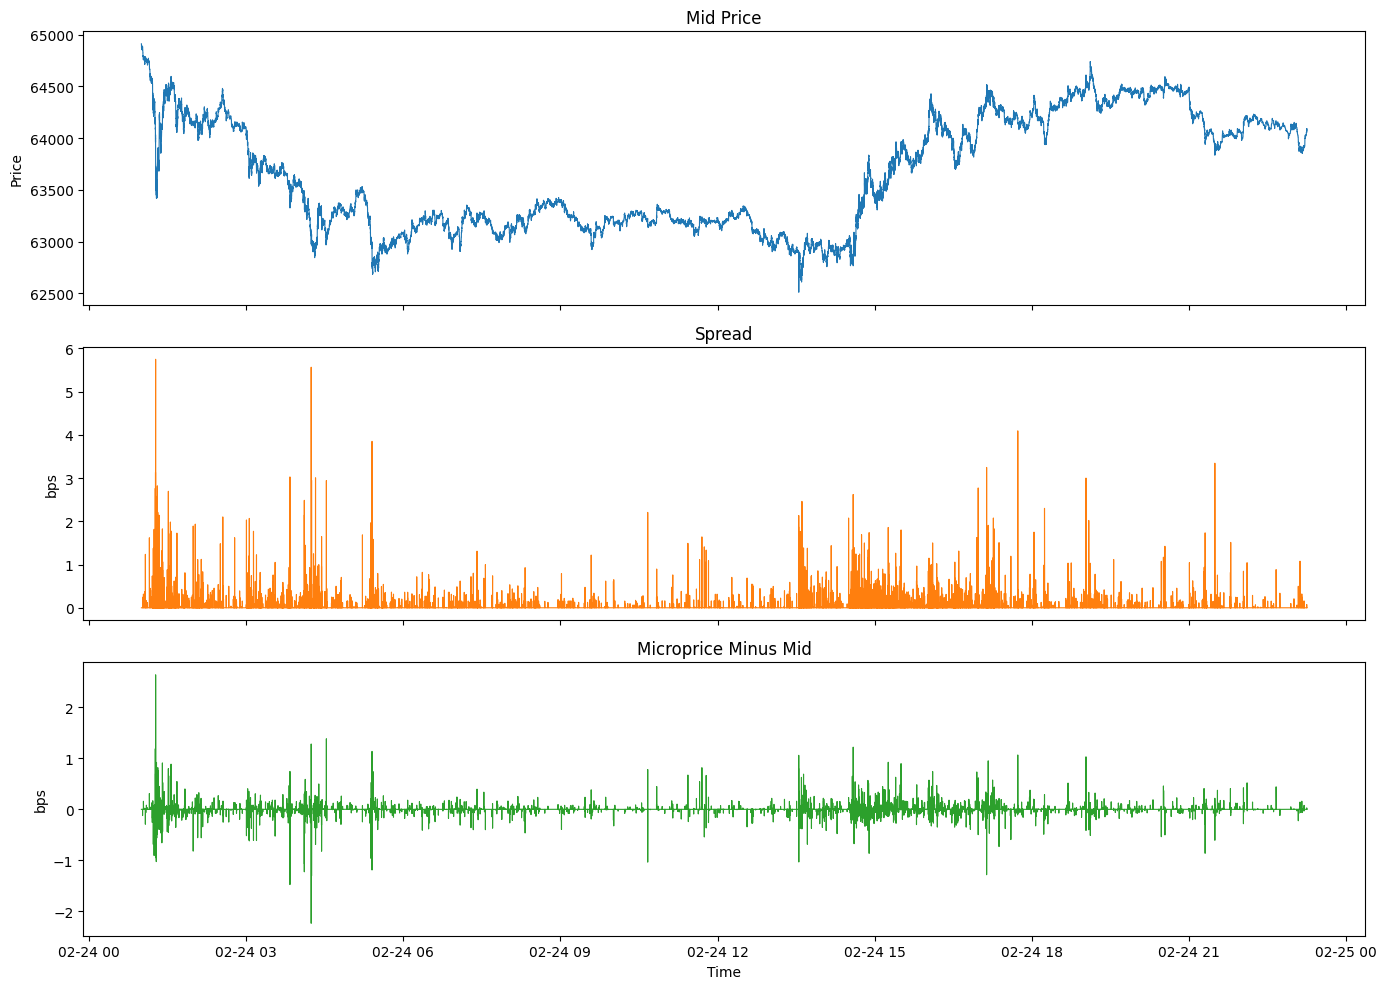

In [8]:
price_view = top_of_book[["ts", "mid", "spread_bps", "microprice"]].copy()
price_view["microprice_minus_mid_bps"] = 1e4 * (price_view["microprice"] - price_view["mid"]) / price_view["mid"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(price_view["ts"], price_view["mid"], linewidth=0.8)
axes[0].set_title("Mid Price")
axes[0].set_ylabel("Price")

axes[1].plot(price_view["ts"], price_view["spread_bps"], linewidth=0.8, color="tab:orange")
axes[1].set_title("Spread")
axes[1].set_ylabel("bps")

axes[2].plot(price_view["ts"], price_view["microprice_minus_mid_bps"], linewidth=0.8, color="tab:green")
axes[2].set_title("Microprice Minus Mid")
axes[2].set_ylabel("bps")
axes[2].set_xlabel("Time")

fig.tight_layout()

## Return Analysis

In [9]:
from stats.features.returns import forward_returns

horizon_ms = [int(pd.Timedelta(h).total_seconds() * 1000) for h in return_horizons]
mid = market_grid["mid"].astype(float)
returns = forward_returns(mid, horizons_ms=horizon_ms, grid_freq=grid_freq, log=True)
returns.columns = [f"fwd_log_ret_{h}" for h in return_horizons]

step_returns = np.log(mid).diff()
event_returns = np.log(top_of_book["mid"]).diff() if not top_of_book.empty else pd.Series(dtype=float)

def summarize_series(name: str, series: pd.Series) -> dict[str, float | str]:
    clean = series.replace([np.inf, -np.inf], np.nan).dropna()
    if clean.empty:
        return {"series": name, "count": 0}
    return {
        "series": name,
        "count": int(clean.shape[0]),
        "mean": float(clean.mean()),
        "std": float(clean.std()),
        "skew": float(clean.skew()),
        "kurtosis": float(clean.kurtosis()),
        "q01": float(clean.quantile(0.01)),
        "median": float(clean.median()),
        "q99": float(clean.quantile(0.99)),
        "zero_share": float((clean == 0).mean()),
    }


return_summary = pd.DataFrame(
    [summarize_series(f"event_log_ret", event_returns)]
    + [summarize_series(col, returns[col]) for col in returns.columns]
)
return_summary

,series,count,mean,std,skew,kurtosis,q01,median,q99,zero_share
0,event_log_ret,717214,-1.821264e-08,0.000027,-2.086586,257.227129,-0.000088,0.000000e+00,0.000088,0.897763
1,fwd_log_ret_1s,80096,-1.630838e-07,0.000097,-0.800171,40.229257,-0.000295,0.000000e+00,0.000291,0.595323
2,fwd_log_ret_5s,80092,-8.078515e-07,0.000234,-0.463367,18.423608,-0.000675,0.000000e+00,0.000665,0.206488
3,fwd_log_ret_30s,80067,-4.720873e-06,0.000606,-0.171533,14.549387,-0.001678,0.000000e+00,0.001667,0.007744
4,fwd_log_ret_1min,80037,-9.551703e-06,0.000864,-0.529295,13.405269,-0.002335,-7.755302e-07,0.002343,0.002899


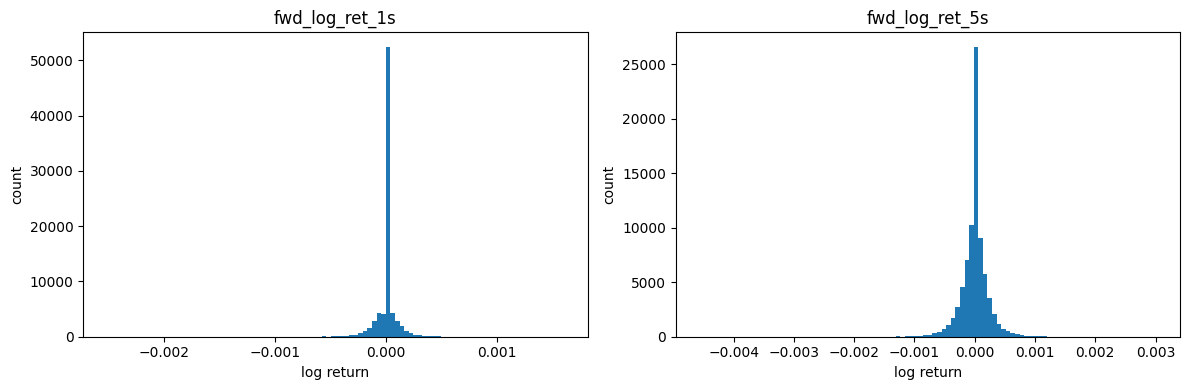

In [10]:
fig, axes = plt.subplots(1, min(2, len(returns.columns)), figsize=(12, 4))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
for ax, column in zip(axes, returns.columns[:2]):
    values = returns[column].dropna()
    ax.hist(values, bins=100)
    ax.set_title(column)
    ax.set_xlabel("log return")
    ax.set_ylabel("count")
fig.tight_layout()

## Volatility

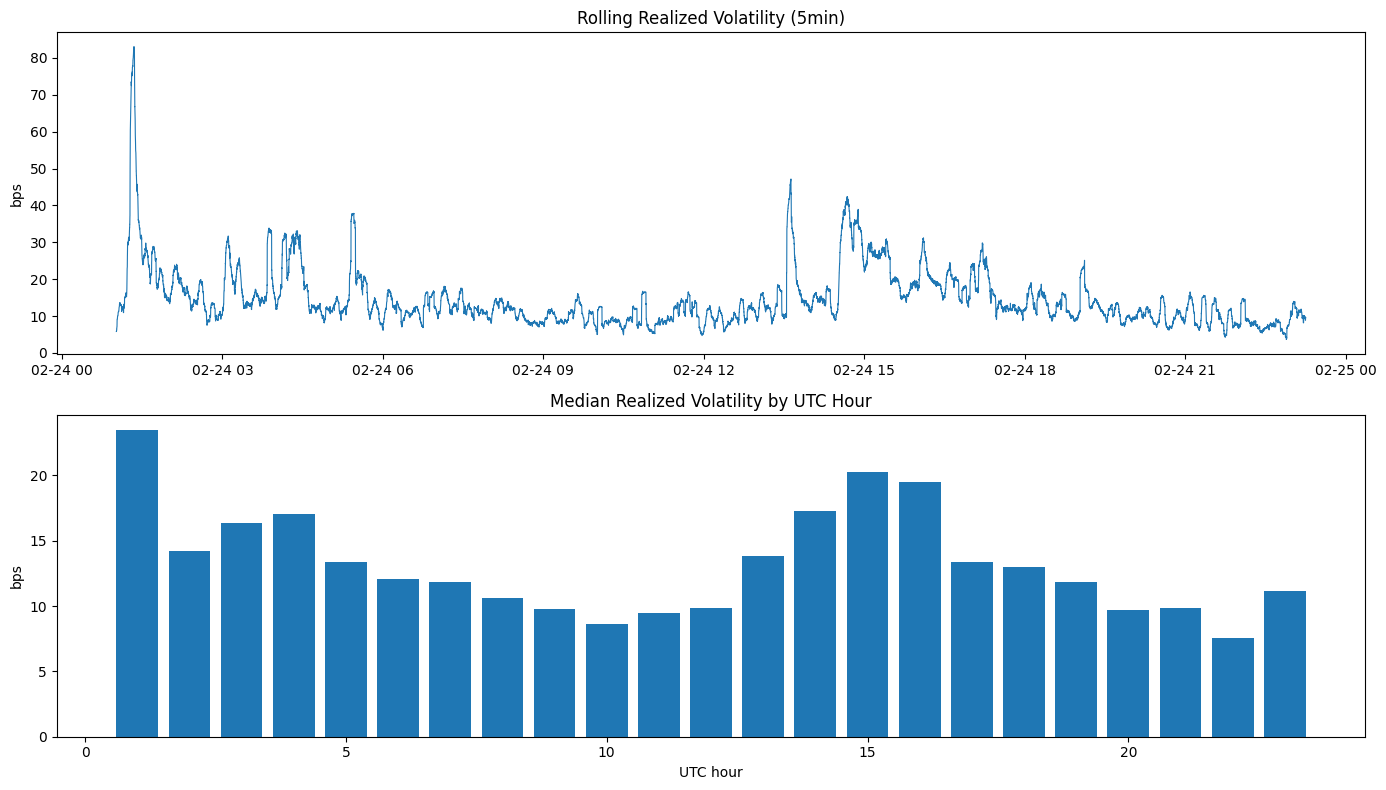

In [11]:
step = pd.Timedelta(grid_freq)
window_bars = max(1, int(pd.Timedelta(vol_window) / step))
rolling_rv = step_returns.pow(2).rolling(window_bars, min_periods=max(2, window_bars // 5)).sum().pow(0.5)
rolling_rv_bps = 1e4 * rolling_rv
vol_df = pd.DataFrame({"rv_bps": rolling_rv_bps})
vol_df["hour_utc"] = vol_df.index.hour
intraday_vol = vol_df.groupby("hour_utc")["rv_bps"].median()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(vol_df.index, vol_df["rv_bps"], linewidth=0.8)
axes[0].set_title(f"Rolling Realized Volatility ({vol_window})")
axes[0].set_ylabel("bps")

axes[1].bar(intraday_vol.index, intraday_vol.values, width=0.8)
axes[1].set_title("Median Realized Volatility by UTC Hour")
axes[1].set_xlabel("UTC hour")
axes[1].set_ylabel("bps")
fig.tight_layout()

## Trade Activity

Trade quantities use the base asset of the symbol and trade notional uses the quote asset. Signed columns are positive for buyer-initiated trades and negative for seller-initiated trades.

### Trade Summary Guide

Trade quantity is the amount of the base asset that changed hands. Trade notional is the value of that trade in the quote asset. For `BTCUSDC`, quantity is measured in `BTC` and notional is measured in `USDC`.

In [12]:
trade_summary_guide = pd.DataFrame(
    {
        "field": [
            "trade_count",
            "buy_share",
            "median_trade_qty",
            "p99_trade_qty",
            "median_notional",
            "signed_qty_sum",
            "signed_notional_sum",
        ],
        "meaning": [
            "Number of recorded trades in the loaded day.",
            "Share of trades with buyer-initiated aggressor side.",
            "Median trade size in base asset units.",
            "99th percentile trade size in base asset units.",
            "Median trade notional in quote asset units.",
            "Sum of signed trade quantity, positive for buy-initiated trades and negative for sell-initiated trades.",
            "Sum of signed trade notional, positive for buy-initiated trades and negative for sell-initiated trades.",
        ],
        "unit": [
            "count",
            "fraction",
            "base asset",
            "base asset",
            "quote asset",
            "base asset",
            "quote asset",
        ],
    }
)
trade_summary_guide

,field,meaning,unit
0,trade_count,Number of recorded trades in the loaded day.,count
1,buy_share,Share of trades with buyer-initiated aggressor...,fraction
2,median_trade_qty,Median trade size in base asset units.,base asset
3,p99_trade_qty,99th percentile trade size in base asset units.,base asset
4,median_notional,Median trade notional in quote asset units.,quote asset
5,signed_qty_sum,"Sum of signed trade quantity, positive for buy...",base asset
6,signed_notional_sum,"Sum of signed trade notional, positive for buy...",quote asset


In [13]:
trade_summary = pd.DataFrame(
    {
        "field": [
            "trade_count",
            "buy_share",
            "median_trade_qty",
            "p99_trade_qty",
            "median_notional",
            "signed_qty_sum",
            "signed_notional_sum",
        ],
        "value": [
            int(len(trades)),
            float((trades["aggr_sign"] > 0).mean()) if not trades.empty else np.nan,
            float(trades["qty"].median()) if not trades.empty else np.nan,
            float(trades["qty"].quantile(0.99)) if not trades.empty else np.nan,
            float(trades["notional"].median()) if not trades.empty else np.nan,
            float(trades["signed_qty"].sum()) if not trades.empty else np.nan,
            float(trades["signed_notional"].sum()) if not trades.empty else np.nan,
        ],
    }
)
trade_summary

,field,value
0,trade_count,9.142060e+05
1,buy_share,4.193694e-01
2,median_trade_qty,9.000000e-05
3,p99_trade_qty,1.094695e-01
4,median_notional,5.700118e+00
5,signed_qty_sum,-6.425934e+02
6,signed_notional_sum,-4.083572e+07


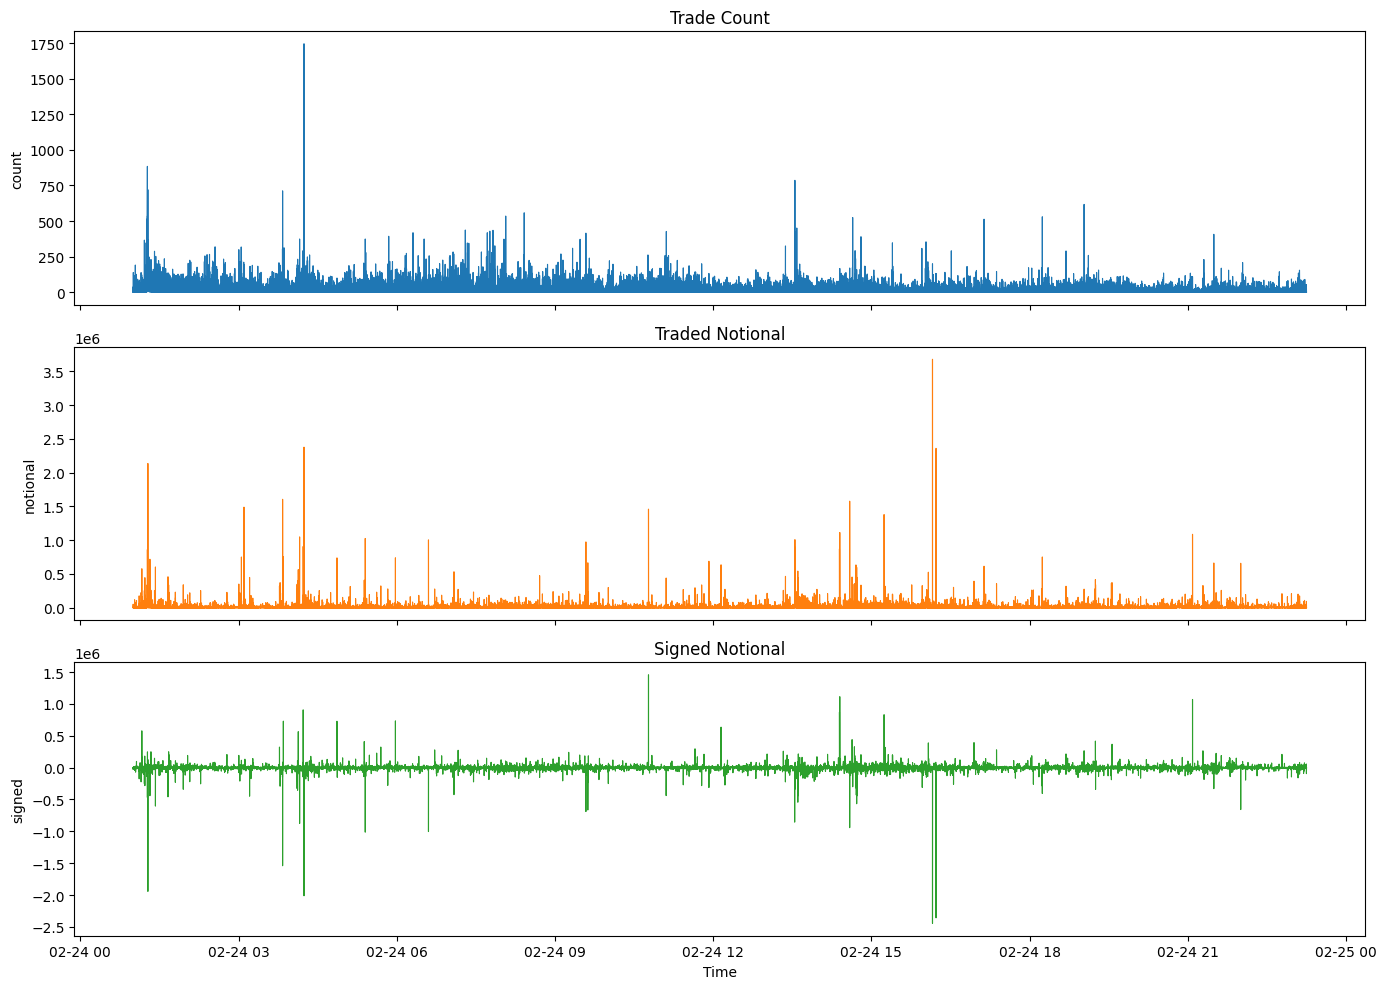

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(market_grid.index, market_grid["trade_count"].fillna(0), linewidth=0.8)
axes[0].set_title("Trade Count")
axes[0].set_ylabel("count")

axes[1].plot(market_grid.index, market_grid["total_notional"].fillna(0), linewidth=0.8, color="tab:orange")
axes[1].set_title("Traded Notional")
axes[1].set_ylabel("notional")

axes[2].plot(market_grid.index, market_grid["signed_notional"].fillna(0), linewidth=0.8, color="tab:green")
axes[2].set_title("Signed Notional")
axes[2].set_ylabel("signed")
axes[2].set_xlabel("Time")

fig.tight_layout()

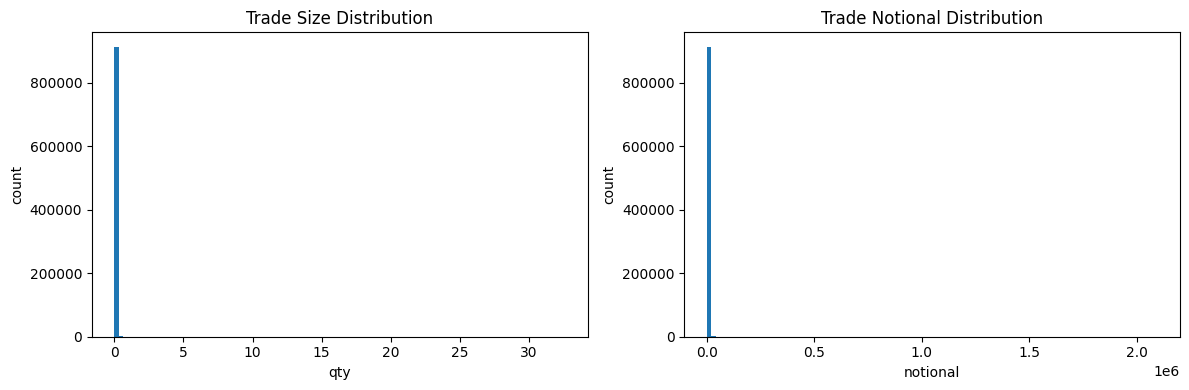

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(trades["qty"].dropna(), bins=100)
axes[0].set_title("Trade Size Distribution")
axes[0].set_xlabel("qty")
axes[0].set_ylabel("count")

axes[1].hist(trades["notional"].dropna(), bins=100)
axes[1].set_title("Trade Notional Distribution")
axes[1].set_xlabel("notional")
axes[1].set_ylabel("count")
fig.tight_layout()

## Book State

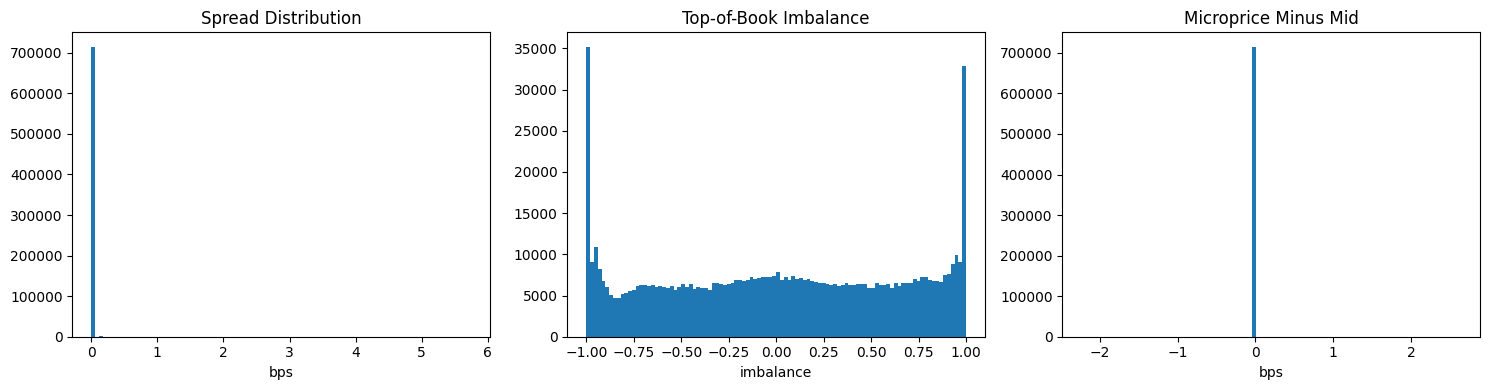

In [16]:
book_stats = top_of_book.copy()
book_stats["imbalance_1"] = (book_stats["bid1_qty"] - book_stats["ask1_qty"]) / (book_stats["bid1_qty"] + book_stats["ask1_qty"]).replace(0, np.nan)
book_stats["microprice_minus_mid_bps"] = 1e4 * (book_stats["microprice"] - book_stats["mid"]) / book_stats["mid"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(book_stats["spread_bps"].dropna(), bins=100)
axes[0].set_title("Spread Distribution")
axes[0].set_xlabel("bps")

axes[1].hist(book_stats["imbalance_1"].dropna(), bins=100)
axes[1].set_title("Top-of-Book Imbalance")
axes[1].set_xlabel("imbalance")

axes[2].hist(book_stats["microprice_minus_mid_bps"].dropna(), bins=100)
axes[2].set_title("Microprice Minus Mid")
axes[2].set_xlabel("bps")
fig.tight_layout()

## Simple Relationships

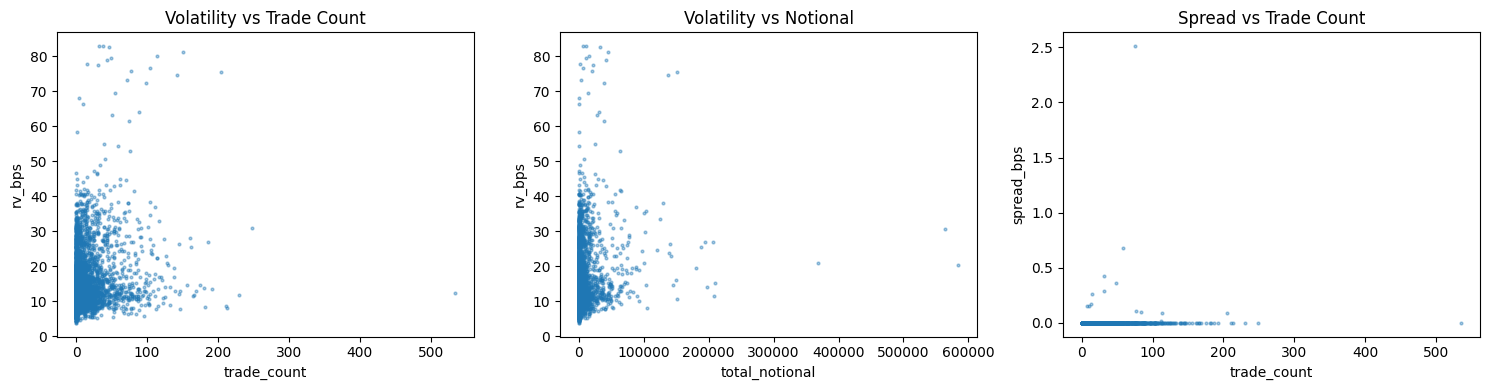

In [17]:
analysis_df = market_grid[["trade_count", "total_notional", "signed_notional", "spread_bps", "mid"]].copy()
analysis_df["rv_bps"] = rolling_rv_bps
analysis_df = analysis_df.dropna()
sample = analysis_df.iloc[::max(1, len(analysis_df) // 5000)].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(sample["trade_count"], sample["rv_bps"], s=4, alpha=0.4)
axes[0].set_title("Volatility vs Trade Count")
axes[0].set_xlabel("trade_count")
axes[0].set_ylabel("rv_bps")

axes[1].scatter(sample["total_notional"], sample["rv_bps"], s=4, alpha=0.4)
axes[1].set_title("Volatility vs Notional")
axes[1].set_xlabel("total_notional")
axes[1].set_ylabel("rv_bps")

axes[2].scatter(sample["trade_count"], sample["spread_bps"], s=4, alpha=0.4)
axes[2].set_title("Spread vs Trade Count")
axes[2].set_xlabel("trade_count")
axes[2].set_ylabel("spread_bps")
fig.tight_layout()

## Short Takeaways

In [18]:
median_spread = float(top_of_book["spread_bps"].median()) if not top_of_book.empty else np.nan
median_rv = float(rolling_rv_bps.median()) if not rolling_rv_bps.dropna().empty else np.nan
buy_share = float((trades["aggr_sign"] > 0).mean()) if not trades.empty else np.nan
signed_notional = float(trades["signed_notional"].sum()) if not trades.empty else np.nan

print(f"Day: {dataset.symbol} {dataset.day}")
print(f"Replay policy: {replay_info['replay_on_gap']} | kept {replay_info['segments_kept']} of {replay_info['segments_total']} segments")
print(f"Median spread: {median_spread:.4f} bps")
print(f"Median rolling realized vol ({vol_window}): {median_rv:.4f} bps")
print(f"Aggressive buy share: {buy_share:.3f}")
print(f"Net signed notional: {signed_notional:,.2f}")

Day: BTCUSDC 20260224
Replay policy: skip-segment | kept 1 of 1 segments
Median spread: 0.0016 bps
Median rolling realized vol (5min): 12.4254 bps
Aggressive buy share: 0.419
Net signed notional: -40,835,719.36
